# FDTD on GDSFactory+ Cloud

[MEEP](https://meep.readthedocs.io/) is an open-source FDTD electromagnetic simulator. This notebook demonstrates using the `gsim.meep` API to run an S-parameter simulation and visualize the results.

**Requirements:**

- GDSFactory Simulation SDK: `uv pip install gsim`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Load a pcell from generic PDK

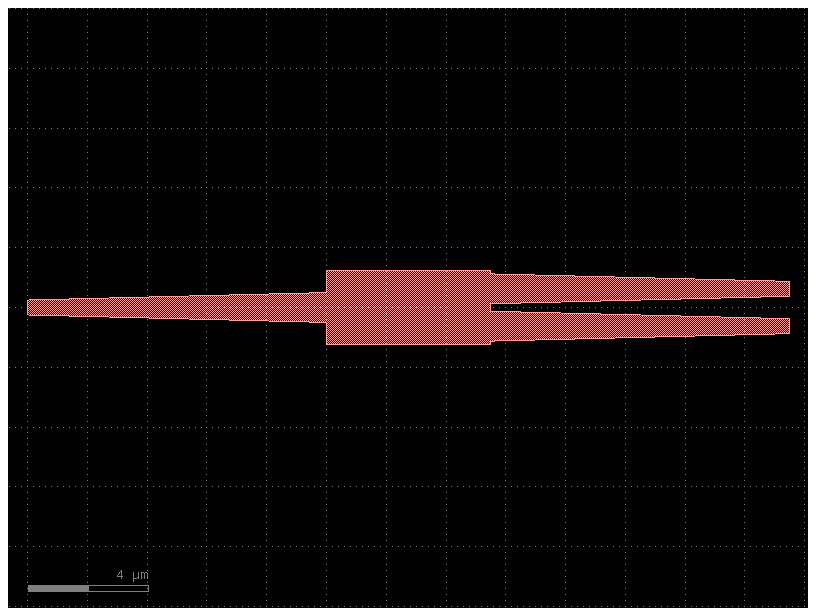

In [9]:
import gdsfactory as gf
from gdsfactory.gpdk import PDK

PDK.activate()

c = gf.get_component("mmi1x2")
c

### Configure and run simulation

In [10]:
from gsim import meep

sim = meep.Simulation()

sim.geometry(component=c, z_crop="auto")
sim.materials = {"si": 3.47, "SiO2": 1.44}
sim.source(port="o1", wavelength=1.55, wavelength_span=0.01, num_freqs=11)
sim.monitors = ["o1", "o2", "o3"]
sim.domain(pml=1.0, margin=3)
sim.solver(resolution=25, simplify_tol=0.01, save_animation=True, verbose_interval=5.0)
sim.solver.stop_after_sources(time=110)

print(sim.validate_config())

Stack validation: PASSED
Warnings:
  - No stack configured. Will use active PDK with defaults.


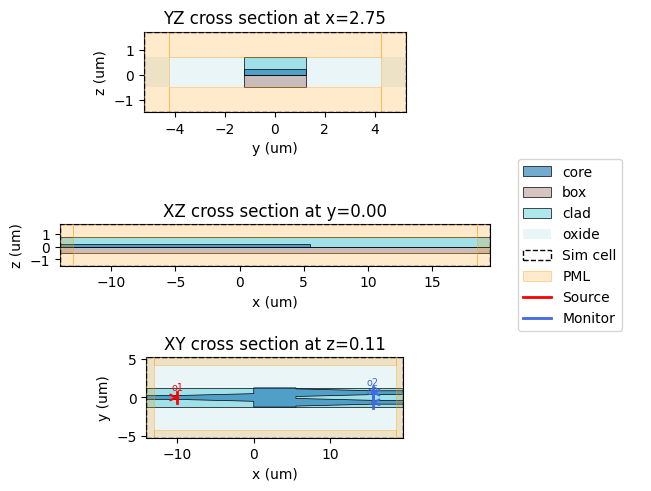

In [11]:
sim.plot_2d(slices="xyz")

### Run simulation on cloud

In [ ]:
# Run on GDSFactory+ cloud
# result = sim.run()

  meep-2e6a1d1a  completed  25m 23s
Extracting results.tar.gz...
Downloaded 382 files to /Users/vahid/doplaydo/gsim/nbs/sim-data-meep-2e6a1d1a


In [6]:
from gsim.meep.models.results import SParameterResult

result = SParameterResult.from_directory("sim-data-meep-2e6a1d1a/results")
# result.plot(db=True)
# result.plot_plotly(keys=["s21", "s31"])
result.plot_interactive()

In [15]:
result.show_animation()